In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.sample import sample_gen
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Compare training dataset against Niu et al. CA-wide raster
# (binary: 0 = no plastic, 1 = plastic presence)

CA_RASTER_PATH = "niu_greenhouse/PCG_CA_Result.tif"
TRAINING_DATA_PATH = "data/Tayloretal_TrainingData.csv"  
LABEL_COL = "Type" # mulch, hoop, other

train_gdf = pd.read_csv(TRAINING_DATA_PATH)
train_gdf = gpd.GeoDataFrame(
    train_gdf,
    geometry=gpd.points_from_xy(train_gdf.Longitude, train_gdf.Latitude),
    crs="EPSG:4326"  # assuming the CSV has lat/lon in WGS84
)

# Ensure training data CRS matches the raster CRS
with rasterio.open(CA_RASTER_PATH) as src:
    raster_crs = src.crs
print(raster_crs)
print(train_gdf.crs)

train_gdf.head()
train_gdf[LABEL_COL] = train_gdf[LABEL_COL].replace({"black mulch": "mulch", "blackmulch": "mulch"})

# 404 points in 2020
train_gdf["Date"] = pd.to_datetime(train_gdf["Date"])
n_2020 = (train_gdf["Date"].dt.year == 2020).sum()
print(f"Points in 2020: {n_2020}")

# points in 2019 to 2021
n_2019_2021 = ((train_gdf["Date"].dt.year >= 2019) & (train_gdf["Date"].dt.year <= 2021)).sum()
print(f"Points in 2019 to 2021: {n_2019_2021}")

train_gdf_2020 = train_gdf[train_gdf["Date"].dt.year == 2020].copy()
train_gdf_2019_2021 = train_gdf[
    (train_gdf["Date"].dt.year >= 2019) & (train_gdf["Date"].dt.year <= 2021)
].copy()


EPSG:4326
EPSG:4326
Points in 2020: 404
Points in 2019 to 2021: 1168


Raster prediction counts by original training class (mulch/hoop/other):
  training_label  raster_value  count
0           hoop             0    201
1           hoop             1    161
2          mulch             0    327
3          mulch             1     22
4          other             0    432
5          other             1     25

Proportion of raster predictions within each training class:
  training_label  raster_value  proportion
0           hoop             0    0.555249
1           hoop             1    0.444751
2          mulch             0    0.936963
3          mulch             1    0.063037
4          other             0    0.945295
5          other             1    0.054705


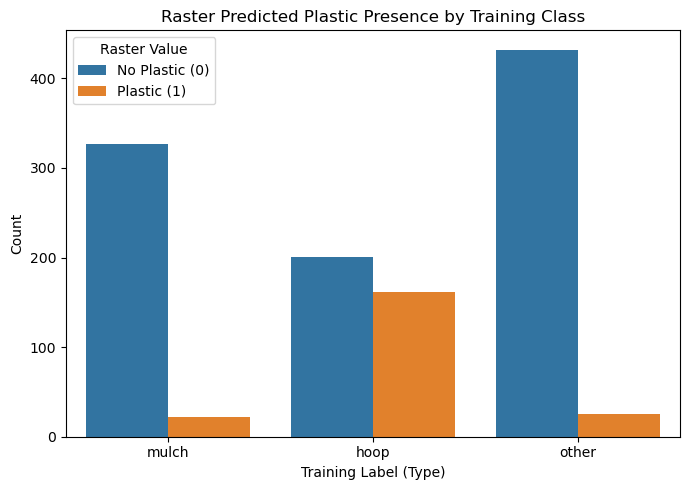

Accuracy:  0.527
Precision: 0.880
Recall:    0.257
F1-score:  0.398

              precision    recall  f1-score   support

  No Plastic       0.45      0.95      0.61       457
     Plastic       0.88      0.26      0.40       711

    accuracy                           0.53      1168
   macro avg       0.66      0.60      0.50      1168
weighted avg       0.71      0.53      0.48      1168



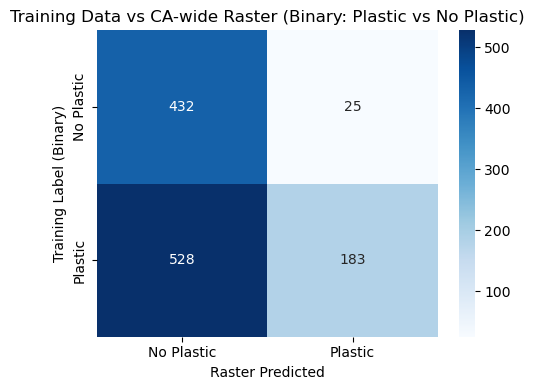

Points agreeing (binary): 615 / 1168 (52.7%)


In [4]:
# select which trainind df to use (year filter)
train_gdf = train_gdf_2019_2021  # or train_gdf_2019_2021

# Sample raster values at training point locations
coords = [(geom.x, geom.y) for geom in train_gdf.geometry]

with rasterio.open(CA_RASTER_PATH) as src:
    sampled_values = [val[0] for val in sample_gen(src, coords)]

train_gdf["raster_value"] = sampled_values
train_gdf.head()

# Drop any points where raster sampling returned nodata (e.g. negative or nan)
valid = train_gdf["raster_value"].isin([0, 1])
comparison_df = train_gdf.loc[valid, [LABEL_COL, "raster_value"]].copy()
comparison_df.columns = ["training_label", "raster_value"]

# Map training labels (mulch, hoop, other) to binary plastic presence
PLASTIC_CLASSES = ["mulch", "hoop"]
comparison_df["training_binary"] = comparison_df["training_label"].apply(
    lambda x: 1 if x in PLASTIC_CLASSES else 0
)
comparison_df.head()

# ---------------------------------------------------------
# Breakdown: how often raster predicts plastic/no-plastic per original class
# ---------------------------------------------------------
class_breakdown = (
    comparison_df.groupby(["training_label", "raster_value"])
    .size()
    .reset_index(name="count")
)
print("Raster prediction counts by original training class (mulch/hoop/other):")
print(class_breakdown)
print()

# Proportion table: for each class, % predicted as plastic vs not
prop_table = (
    comparison_df.groupby("training_label")["raster_value"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)
print("Proportion of raster predictions within each training class:")
print(prop_table)

# Visualize breakdown by class
plt.figure(figsize=(7, 5))
sns.countplot(
    data=comparison_df,
    x="training_label",
    hue="raster_value",
    order=["mulch", "hoop", "other"],
)
plt.xlabel("Training Label (Type)")
plt.ylabel("Count")
plt.title("Raster Predicted Plastic Presence by Training Class")
plt.legend(title="Raster Value", labels=["No Plastic (0)", "Plastic (1)"])
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Simple binary comparison: plastic (mulch/hoop) vs not (other)
# ---------------------------------------------------------
y_true = comparison_df["training_binary"].astype(int)
y_pred = comparison_df["raster_value"].astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print()
print(classification_report(y_true, y_pred, target_names=["No Plastic", "Plastic"]))

# ---------------------------------------------------------
# Confusion matrix visualization (binary)
# ---------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Plastic", "Plastic"],
    yticklabels=["No Plastic", "Plastic"],
)
plt.xlabel("Raster Predicted")
plt.ylabel("Training Label (Binary)")
plt.title("Training Data vs CA-wide Raster (Binary: Plastic vs No Plastic)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Summary table of agreement/disagreement (binary)
# ---------------------------------------------------------
comparison_df["agree"] = comparison_df["training_binary"] == comparison_df["raster_value"]

summary = (
    comparison_df.groupby(["training_binary", "raster_value"])
    .size()
    .reset_index(name="count")
)
summary

n_agree = comparison_df["agree"].sum()
n_total = len(comparison_df)
print(f"Points agreeing (binary): {n_agree} / {n_total} ({100 * n_agree / n_total:.1f}%)")


In [5]:
import folium
import numpy as np
from rasterio.warp import transform_bounds

# Reproject raster bounds to WGS84 for folium
with rasterio.open(CA_RASTER_PATH) as src:
    raster_data = src.read(1)
    bounds_wgs84 = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
    raster_transform = src.transform

# Build RGBA overlay image: blue = no plastic, red = plastic, transparent = nodata
overlay = np.zeros((*raster_data.shape, 4), dtype=np.uint8)
overlay[raster_data == 0] = [0, 0, 255, 120]   # blue, semi-transparent
overlay[raster_data == 1] = [255, 0, 0, 180]   # red
mask_valid = np.isin(raster_data, [0, 1])
overlay[~mask_valid] = [0, 0, 0, 0]  # transparent for nodata

# folium image bounds: [[south, west], [north, east]]
image_bounds = [
    [bounds_wgs84[1], bounds_wgs84[0]],
    [bounds_wgs84[3], bounds_wgs84[2]],
]

# Center map on raster bounds
center_lat = (bounds_wgs84[1] + bounds_wgs84[3]) / 2
center_lon = (bounds_wgs84[0] + bounds_wgs84[2]) / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="CartoDB positron")

folium.raster_layers.ImageOverlay(
    image=overlay,
    bounds=image_bounds,
    opacity=0.7,
    name="CA-wide Raster (blue=no plastic, red=plastic)",
).add_to(m)

# Plot training points colored by binary label
for idx, row in comparison_df.iterrows():
    lat = train_gdf.loc[idx, "Latitude"]
    lon = train_gdf.loc[idx, "Longitude"]
    color = "red" if row["training_binary"] == 1 else "blue"
    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color="black",
        weight=0.5,
        fill=True,
        fill_color=color,
        fill_opacity=0.9,
        popup=f"Label: {row['training_label']}",
    ).add_to(m)

folium.LayerControl().add_to(m)
m

import matplotlib.colors as mcolors

with rasterio.open(CA_RASTER_PATH) as src:
    raster_data = src.read(1)
    raster_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    raster_transform = src.transform

# Custom colormap for raster: 0 = blue (no plastic), 1 = red (plastic)
raster_cmap = mcolors.ListedColormap(["blue", "red"])

fig, ax = plt.subplots(figsize=(12, 12))

# Plot raster
show(
    raster_data,
    transform=raster_transform,
    ax=ax,
    cmap=raster_cmap,
    vmin=0,
    vmax=1,
)

# Plot training points on top, colored by binary label
colors = comparison_df["training_binary"].map({0: "blue", 1: "red"})
ax.scatter(
    train_gdf.loc[comparison_df.index, "Longitude"],
    train_gdf.loc[comparison_df.index, "Latitude"],
    c=colors,
    edgecolor="black",
    s=20,
    linewidth=0.5,
    label="Training Points",
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

MemoryError: Unable to allocate 14.8 GiB for an array with shape (1982068135,) and data type int64